In [6]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import sys
import os

# src klasörünü python path'ine ekle (gerekirse)
sys.path.append(os.path.abspath('.'))

from src.prior_sensitivity_lab.domain.beta_binomial import posterior_params, shrinkage

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

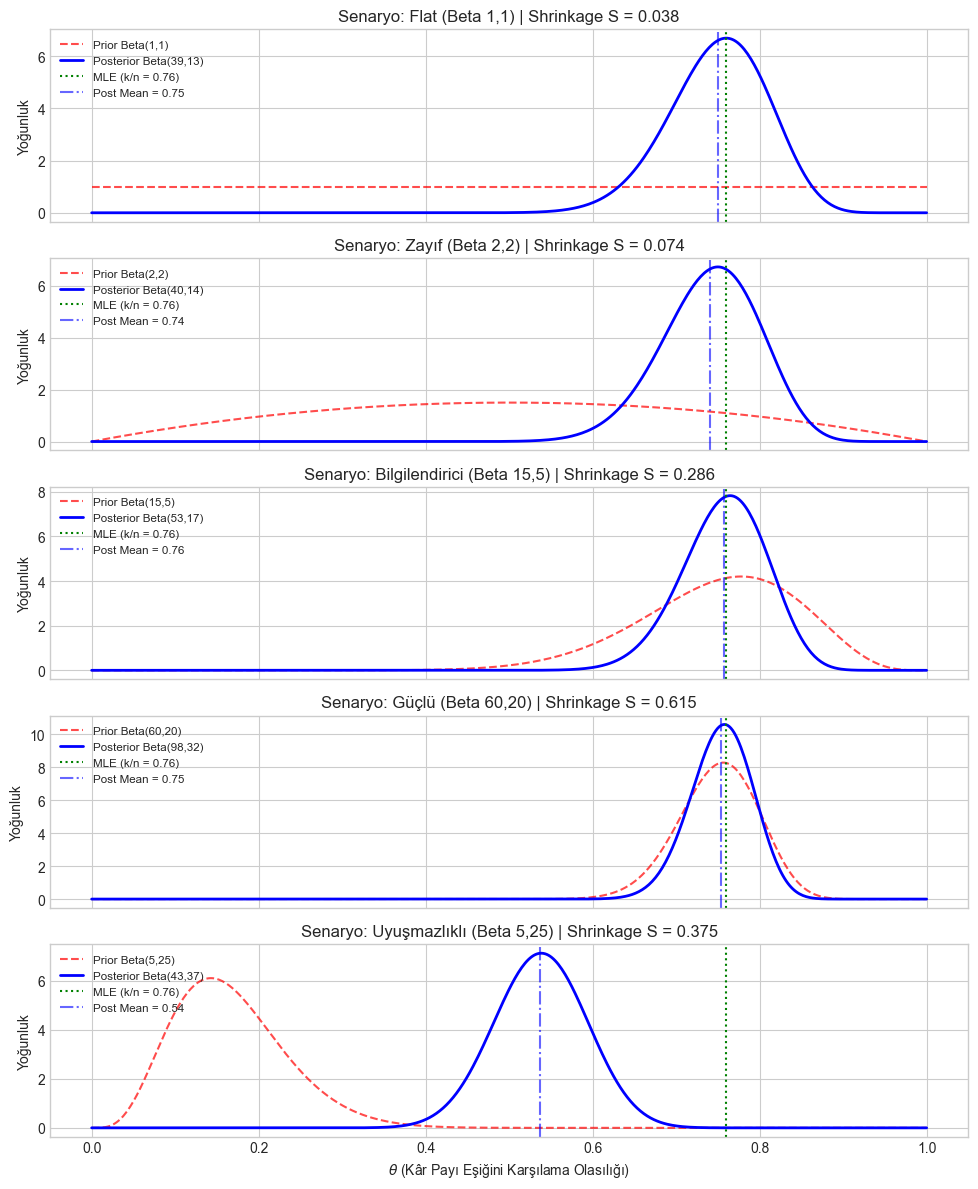

In [7]:
# Sabit Veri Parametreleri
n = 50
k = 38
theta = np.linspace(0, 1, 500)

priors = {
    'Flat (Beta 1,1)': (1, 1),
    'Zayıf (Beta 2,2)': (2, 2),
    'Bilgilendirici (Beta 15,5)': (15, 5),
    'Güçlü (Beta 60,20)': (60, 20),
    'Uyuşmazlıklı (Beta 5,25)': (5, 25)
}

fig, axes = plt.subplots(len(priors), 1, figsize=(10, 12), sharex=True)

for ax, (name, (a_p, b_p)) in zip(axes, priors.items()):
    # src/ altındaki fonksiyonları çağırıyoruz!
    a_po, b_po = posterior_params(a_p, b_p, k, n)
    S = shrinkage(a_p, b_p, n)
    
    # Ortalama ve MLE hesapları
    prior_mean = a_p / (a_p + b_p)
    post_mean = a_po / (a_po + b_po)
    mle = k / n
    
    # PDF'ler
    prior_pdf = stats.beta.pdf(theta, a_p, b_p)
    post_pdf = stats.beta.pdf(theta, a_po, b_po)
    
    # Çizimler
    ax.plot(theta, prior_pdf, 'r--', label=f'Prior Beta({a_p},{b_p})', alpha=0.7)
    ax.plot(theta, post_pdf, 'b-', label=f'Posterior Beta({a_po},{b_po})', lw=2)
    ax.axvline(mle, color='green', linestyle=':', label=f'MLE (k/n = {mle:.2f})')
    ax.axvline(post_mean, color='blue', linestyle='-.', alpha=0.6, label=f'Post Mean = {post_mean:.2f}')
    
    ax.set_title(f"Senaryo: {name} | Shrinkage S = {S:.3f}")
    ax.set_ylabel("Yoğunluk")
    ax.legend(loc='upper left', fontsize='small')

axes[-1].set_xlabel(r"$\theta$ (Kâr Payı Eşiğini Karşılama Olasılığı)")
plt.tight_layout()
plt.show()

In [9]:
fig.savefig("assets/beta_binomial_sensitivity.png", dpi=300, bbox_inches='tight')

In [10]:
from src.prior_sensitivity_lab.distances.kl import kl_divergence

# Flat posterior (referans): Beta(39, 13)
# Diğer 4 senaryonun posterior parametreleri ile KL hesaplayalım:
posteriors = {
    "Zayıf": (40, 14),
    "Bilgilendirici": (53, 17),
    "Güçlü": (98, 32),
    "Uyuşmazlıklı": (43, 37)
}

print("--- Flat Posterior'a Göre KL Iraksama Değerleri ---")
for name, (a_p, b_p) in posteriors.items():
    kl_val = kl_divergence(39, 13, a_p, b_p)
    print(f"{name} Senaryosu: {kl_val:.4f}")

--- Flat Posterior'a Göre KL Iraksama Değerleri ---
Zayıf Senaryosu: 0.0135
Bilgilendirici Senaryosu: 0.0315
Güçlü Senaryosu: 0.2954
Uyuşmazlıklı Senaryosu: 8.7928
